# RAG & Agentic RAG — LangChain + Groq (free)

Cell-by-cell tutorial. Each section maps to a box in the diagram.

**Free stack:** Groq LLM · local HuggingFace embeddings · FAISS · LangGraph.

## 0. Install & configure

In [ ]:
# Run once. In Colab keep this; locally you can use requirements.txt instead.
%pip install -q langchain langchain-core langchain-community \
    langchain-groq langchain-huggingface sentence-transformers \
    faiss-cpu langgraph duckduckgo-search python-dotenv

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()  # reads GROQ_API_KEY from a .env file

# In Colab (no .env), uncomment and paste your free key from console.groq.com/keys:
# import getpass; os.environ['GROQ_API_KEY'] = getpass.getpass('GROQ_API_KEY: ')
assert os.getenv('GROQ_API_KEY'), 'Set GROQ_API_KEY first!'

# Part 1 — Basic RAG (top diagram, 7 steps)

`Query -> Encode -> Index -> Similarity Search -> Context+Query -> LLM -> Response`

### Steps 2+3 — Encode & Index the knowledge base

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# (2) embeddings model — LOCAL, free (first run downloads ~90MB, then cached)
embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

docs = TextLoader('knowledge_base.md', encoding='utf-8').load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=80).split_documents(docs)
print(f'{len(chunks)} chunks')

# (2 encode) + (3 index) happen together here
vector_store = FAISS.from_documents(chunks, embeddings)

9 chunks


### Step 4 — Similarity Search (retriever)

In [9]:
retriever = vector_store.as_retriever(search_kwargs={'k': 2})
for d in retriever.invoke('What is a transformer?'):
    print('-', d.page_content[:80], '...')

- ## What is a Transformer?
The Transformer is a neural network architecture intro ...
- ## What is a Neural Network?
A neural network is a model made of layers of conne ...


### Steps 5+6+7 — Prompt, LLM, Response

In [11]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)  # (6)

prompt = ChatPromptTemplate.from_template(  # (5) context + query
    'Answer the QUESTION using ONLY the CONTEXT.\n'
    'If not in context, say you do not know.\n\n'
    'CONTEXT:\n{context}\n\nQUESTION: {question}\n\nANSWER:'
)

def format_docs(docs):
    return '\n\n'.join(d.page_content for d in docs)

#basic RAG
rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()} #Returns input data as-is or assigns new dictionary keys.
    | prompt | llm | StrOutputParser()  # (7) response
)

In [12]:
print(rag_chain.invoke('What is RAG and why does it reduce hallucinations?'))

RAG (Retrieval-Augmented Generation) is a technique that gives a language model access to an external knowledge base. It reduces hallucinations because it allows the model to retrieve relevant documents and generate an answer grounded in those documents, rather than relying only on what it memorized during training.


# Part 2 — Agentic RAG (bottom diagram, 11 steps)

Now the LLM **decides** (need details? which source?) and **loops** (is the answer relevant?). Built with **LangGraph**.

### The web-search 'Internet' source + shared State

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

def web_search(query: str) -> str:
    try:
        from duckduckgo_search import DDGS
        with DDGS() as ddgs:
            hits = list(ddgs.text(query, max_results=3))
        return '\n\n'.join(h['body'] for h in hits) or 'No results.'
    except Exception as e:
        return f'(web search unavailable: {e})'

class AgentState(TypedDict):
    question: str        # (1)
    updated_query: str   # (3)
    source: str          # (5)
    context: str         # (7)
    generation: str      # (9)
    retries: int         # loop guard

c:\Users\saina\AppData\Local\Programs\Python\Python311\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Nodes = boxes  ·  Decisions = diamonds

In [14]:
# Rewrite query  Agent
def rewrite_query(state):  # (2)->(3)
    p = ChatPromptTemplate.from_template(
        'Rewrite into a clear standalone search query. Return only the query.\n\nQ: {q}')
    q = (p | llm | StrOutputParser()).invoke({'q': state['question']}).strip()
    print('  (2) rewritten ->', q)
    return {'updated_query': q}

# Decision Agent - Need more details or not
def decide_to_retrieve(state):  # (4) YES/NO
    p = ChatPromptTemplate.from_template(
        'Does answering require external facts/data? Reply YES or NO.\n\nQ: {q}')
    d = (p | llm | StrOutputParser()).invoke({'q': state['updated_query']}).strip().upper()
    need = d.startswith('YES')
    print('  (4) need details? ->', 'YES' if need else 'NO')
    return 'retrieve' if need else 'generate'

# Routing Agnet
def route_to_source(state):  # (5)
    p = ChatPromptTemplate.from_template(
        "'vectorstore' = notes on ML/neural nets/transformers/RAG/embeddings/Groq. "
        "'web' = anything else. Reply one word.\n\nQ: {q}")
    c = (p | llm | StrOutputParser()).invoke({'q': state['updated_query']}).strip().lower()
    src = 'web' if 'web' in c else 'vectorstore'
    print('  (5) source ->', src)
    return {'source': src}

# Retireval Agent
def retrieve(state):  # (6)->(7)
    q = state['updated_query']
    if state['source'] == 'web':
        ctx = web_search(q) # Web search tool
    else:
        ctx = '\n\n'.join(d.page_content for d in retriever.invoke(q))
    print('  (6) retrieved from ->', state['source'])
    return {'context': ctx}

# Generate Agent
def generate(state):  # (8)->(9)
    ctx = state.get('context') or '(no context)'
    p = ChatPromptTemplate.from_template(
        'Answer using CONTEXT when helpful.\n\nCONTEXT:\n{c}\n\nQUESTION: {q}\n\nANSWER:')
    a = (p | llm | StrOutputParser()).invoke({'c': ctx, 'q': state['question']})
    print('  (8) generated')
    return {'generation': a}

# Generate Agent
def grade_answer(state):  # (10) YES/NO
    if state['retries'] >= 2:
        print('  (10) max retries -> accept'); return 'acceptable'
    p = ChatPromptTemplate.from_template(
        'Does the ANSWER relevantly address the QUESTION? Reply YES or NO.\n\nQ: {q}\nA: {a}')
    v = (p | llm | StrOutputParser()).invoke({'q': state['question'], 'a': state['generation']}).strip().upper()
    good = v.startswith('YES')
    print('  (10) relevant? ->', 'YES' if good else 'NO')
    return 'acceptable' if good else 'retry'

def bump_retries(state):
    return {'retries': state['retries'] + 1}

### Wire the graph together

In [15]:
g = StateGraph(AgentState)
g.add_node('rewrite_query', rewrite_query)
g.add_node('route_to_source', route_to_source)
g.add_node('retrieve', retrieve)
g.add_node('generate', generate)
g.add_node('bump_retries', bump_retries)

g.add_edge(START, 'rewrite_query')
g.add_conditional_edges('rewrite_query', decide_to_retrieve,
    {'retrieve': 'route_to_source', 'generate': 'generate'})
g.add_edge('route_to_source', 'retrieve')
g.add_edge('retrieve', 'generate')
g.add_conditional_edges('generate', grade_answer,
    {'acceptable': END, 'retry': 'bump_retries'})
g.add_edge('bump_retries', 'rewrite_query')

agent = g.compile()

### Visualise the graph (the diagram, straight from code)

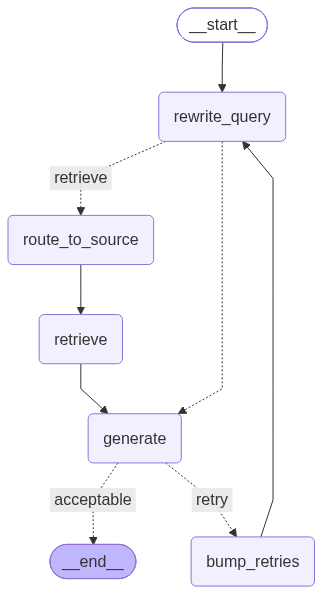

In [16]:
from IPython.display import Image, display
try:
    display(Image(agent.get_graph().draw_mermaid_png()))  # needs internet
except Exception as e:
    print('PNG render failed, showing Mermaid text instead:', e)
    print(agent.get_graph().draw_mermaid())

### Run it — try the 3 branches

In [18]:
for q in ['What is are embedding and RAG?',
          'Who won the 2022 FIFA World Cup?',
          'What is 15 times 12?']:
    print('\n=== Q:', q, '===')
    out = agent.invoke({'question': q, 'retries': 0})
    print('FINAL:', out['generation'][:300])


=== Q: What is are embedding and RAG? ===
  (2) rewritten -> embedding and RAG in artificial intelligence
  (4) need details? -> YES
  (5) source -> vectorstore
  (6) retrieved from -> vectorstore
  (8) generated
  (10) relevant? -> YES
FINAL: Embeddings and RAG are related concepts in natural language processing. 

Embeddings refer to a list of numbers (a vector) that represent the meaning of a piece of text. This allows texts with similar meanings to have vectors that are close together, enabling the discovery of "semantically similar" 

=== Q: Who won the 2022 FIFA World Cup? ===
  (2) rewritten -> 2022 FIFA World Cup winner
  (4) need details? -> YES
  (5) source -> web


C:\Users\saina\AppData\Local\Temp\ipykernel_8860\2543077319.py:7: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


  (6) retrieved from -> web
  (8) generated
  (10) relevant? -> YES
FINAL: Argentina won the 2022 FIFA World Cup, defeating France 4-2 in a penalty shootout after the match ended 3-3 after extra time.

=== Q: What is 15 times 12? ===
  (2) rewritten -> 15 * 12
  (4) need details? -> NO
  (8) generated
  (10) relevant? -> YES
FINAL: To find the answer, we need to multiply 15 by 12. 

15 * 12 = 180

ANSWER: 180
